In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**1.List all unique citites where customer are located**


Total number of unique cities: 4119


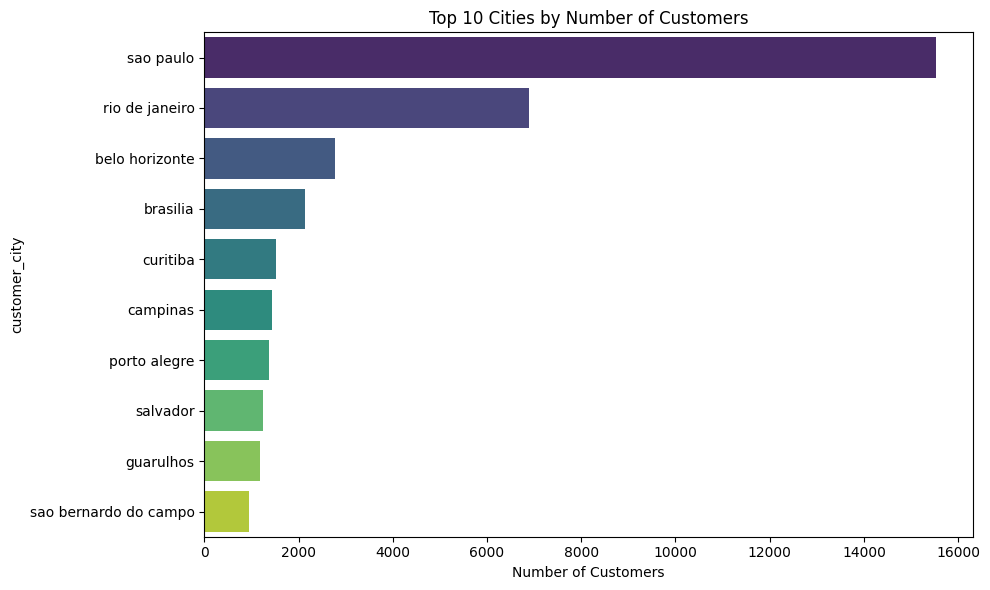

In [5]:
customers_df = pd.read_csv('/kaggle/input/project-for-python/Customers.csv')
unique_cities = customers_df['customer_city'].unique()



print(f"\nTotal number of unique cities: {len(unique_cities)}")

city_counts = customers_df['customer_city'].value_counts().head(10)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index, palette="viridis")
plt.title('Top 10 Cities by Number of Customers')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

**Total Revanue**

In [6]:
payments_df = pd.read_csv('/kaggle/input/project-for-python/payments.csv')
total_sales_revenue = payments_df['payment_value'].sum()
print(f"Total sales revenue: ${total_sales_revenue:.2f}")

Total sales revenue: $16008872.12


**2.Count the number of orders placed in 2017**

In [7]:
orders_df = pd.read_csv('/kaggle/input/project-for-python/orders.csv')
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_2017 = orders_df[orders_df['order_purchase_timestamp'].dt.year == 2017]
count_2017 = len(orders_2017)
print(f"Number of orders placed in 2017: {count_2017}")

Number of orders placed in 2017: 45101


**3.find the total sales per country**

In [8]:

orders_df = pd.read_csv('/kaggle/input/project-for-python/orders.csv')
payments_df = pd.read_csv('/kaggle/input/project-for-python/payments.csv')
customers_df = pd.read_csv('/kaggle/input/project-for-python/Customers.csv')
orders_payments_df = pd.merge(orders_df, payments_df, on='order_id')
orders_payments_customers_df = pd.merge(orders_payments_df, customers_df, on='customer_id')
sales_per_state = orders_payments_customers_df.groupby('customer_state')['payment_value'].sum().reset_index()
sales_per_state.columns = ['State', 'Total Sales']
sales_per_state = sales_per_state.sort_values(by='Total Sales', ascending=False)
sales_per_state.to_csv('sales_per_state.csv', index=False)
print(sales_per_state)

   State  Total Sales
25    SP   5998226.96
18    RJ   2144379.69
10    MG   1872257.26
22    RS    890898.54
17    PR    811156.38
23    SC    623086.43
4     BA    616645.82
6     DF    355141.08
8     GO    350092.31
7     ES    325967.55
15    PE    324850.44
5     CE    279464.03
13    PA    218295.85
12    MT    187029.29
9     MA    152523.02
14    PB    141545.72
11    MS    137534.84
16    PI    108523.97
19    RN    102718.13
1     AL     96962.06
24    SE     75246.25
26    TO     61485.33
20    RO     60866.20
2     AM     27966.93
0     AC     19680.62
3     AP     16262.80
21    RR     10064.62


**4.Calculate the percentage of Order that were Paid in installment**

In [9]:

df_payments = pd.read_csv('/kaggle/input/project-for-python/payments.csv')
total_payments = len(df_payments)
installment_payments = df_payments[df_payments['payment_installments'] > 1]
count_installment_payments = len(installment_payments)
percentage = (count_installment_payments / total_payments) * 100
print(f"Total number of payments: {total_payments}")
print(f"Number of payments with installments: {count_installment_payments}")
print(f"Percentage of payments with installments: {percentage:.2f}%")

Total number of payments: 103886
Number of payments with installments: 51338
Percentage of payments with installments: 49.42%


**5.Count the number of customers from each State.**

In [10]:
df_customers = pd.read_csv('/kaggle/input/project-for-python/Customers.csv')
customers_per_state = (
    df_customers.groupby('customer_state')['customer_id']
    .count()
    .sort_values(ascending=False)
)
print(customers_per_state)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: customer_id, dtype: int64


In [11]:
import pandas as pd
df_customers = pd.read_csv('/kaggle/input/project-for-python/Customers.csv')
customers_per_state = df_customers.groupby('customer_state')['customer_id'].count().sort_values(ascending=False)
top_state = customers_per_state.index[0]
top_count = customers_per_state.iloc[0]
print(f"Top state: {top_state}, Number of customers: {top_count}")


Top state: SP, Number of customers: 41746


# Intermediate Question 
**6.Calculate the number of orders per month in 2018**

In [12]:
df_orders = pd.read_csv('/kaggle/input/project-for-python/orders.csv')
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
orders_2018 = df_orders[df_orders['order_purchase_timestamp'].dt.year == 2018]
orders_per_month_2018 = orders_2018.groupby(orders_2018['order_purchase_timestamp'].dt.month)['order_id'].count()
orders_per_month_2018.index = pd.to_datetime(orders_per_month_2018.index, format='%m').month_name()
print("Number of orders per month in 2018:")
print(orders_per_month_2018)

Number of orders per month in 2018:
order_purchase_timestamp
January      7269
February     6728
March        7211
April        6939
May          6873
June         6167
July         6292
August       6512
September      16
October         4
Name: order_id, dtype: int64


**7.Find the average number of product per order,grouped by customer city.**

In [13]:

orders_df = pd.read_csv('/kaggle/input/project-for-python/orders.csv')
order_items_df = pd.read_csv('/kaggle/input/project-for-python/order_items.csv')
customers_df = pd.read_csv('/kaggle/input/project-for-python/Customers.csv')
orders_items_merged = pd.merge(orders_df, order_items_df, on='order_id')
final_df = pd.merge(orders_items_merged, customers_df, on='customer_id')
products_per_order = final_df.groupby(['order_id', 'customer_city'])['product_id'].count().reset_index()
products_per_order.columns = ['order_id', 'customer_city', 'product_count']
average_products_per_city = products_per_order.groupby('customer_city')['product_count'].mean().reset_index()
average_products_per_city.columns = ['customer_city', 'average_products_per_order']
average_products_per_city_sorted = average_products_per_city.sort_values(by='average_products_per_order', ascending=False)
print("Average number of products per order, grouped by customer city:")
print(average_products_per_city_sorted)

Average number of products per order, grouped by customer city:
       customer_city  average_products_per_order
2619  padre carvalho                         7.0
907      celso ramos                         6.5
756    candido godoi                         6.0
1154           datas                         6.0
2264  matias olimpio                         5.0
...              ...                         ...
1662         indiana                         1.0
1663    indianopolis                         1.0
1664       indiapora                         1.0
1666       indiaroba                         1.0
4109          zortea                         1.0

[4110 rows x 2 columns]


**8.calculate the percentage of total revenue contributed by each product category**

In [14]:
import pandas as pd
products_df = pd.read_csv('/kaggle/input/project-for-python/products.csv')
order_items_df = pd.read_csv('/kaggle/input/project-for-python/order_items.csv')
merged_df = pd.merge(order_items_df, products_df, on='product_id', how='left')
revenue_per_category = merged_df.groupby('product category')['price'].sum().reset_index()
revenue_per_category.columns = ['product_category', 'total_revenue']
total_revenue = revenue_per_category['total_revenue'].sum()
revenue_per_category['percentage_contribution'] = (revenue_per_category['total_revenue'] / total_revenue) * 100
revenue_per_category_sorted = revenue_per_category.sort_values(by='percentage_contribution', ascending=False)
print(revenue_per_category_sorted)

               product_category  total_revenue  percentage_contribution
30                HEALTH BEAUTY     1258681.34                 9.384664
45              Watches present     1205005.68                 8.984461
49               bed table bath     1036988.68                 7.731735
68                sport leisure      988048.97                 7.366843
53         computer accessories      911954.32                 6.799485
..                          ...            ...                      ...
58                      flowers        1110.04                 0.008276
32              House Comfort 2         760.27                 0.005669
50               cds music dvds         730.00                 0.005443
18  Fashion Children's Clothing         569.85                 0.004249
62       insurance and services         283.29                 0.002112

[73 rows x 3 columns]


**9.Identify the correlation between product price and the number of times a product has been purchased.**

In [15]:
import pandas as pd
df_items = pd.read_csv('/kaggle/input/project-for-python/order_items.csv')
product_stats = df_items.groupby('product_id').agg(
    average_price=('price', 'mean'),
    purchase_count=('order_item_id', 'count')
).reset_index()
correlation = product_stats['average_price'].corr(product_stats['purchase_count'])
print(f"The correlation between product price and number of times a product has been purchased is: {correlation}")

The correlation between product price and number of times a product has been purchased is: -0.032139862680945146


**Calculate the total revenue generated by each seller, and rank them by revenue.**

      rank                         seller_id  total_revenue       seller_city  \
857      1  4869f7a5dfa277a7dca6462dcf3b52b2      229472.63           guariba   
1013     2  53243585a1d6dc2643021fd1853d8905      222776.05  lauro de freitas   
881      3  4a3ca9315b744ce9f8e9374361493884      200472.92          ibitinga   
3024     4  fa1c13f2614d7b5c4749cbc52fecda94      194042.03            sumare   
1535     5  7c67e1448b00f6e969d365cea6b010ab      187923.89   itaquaquecetuba   
1560     6  7e93a43ef30c4f03f38b393420bc753a      176431.87           barueri   
2643     7  da8622b14eb17ae2831f4ac5b9dab84a      160236.57        piracicaba   
1505     8  7a67c85e85bb2ce8582c35f2203ad736      141745.53         sao paulo   
192      9  1025f0e2d44d7041d6cf58b6550e0bfa      138968.55         sao paulo   
1824    10  955fee9216a65b617aa5c0531780ce60      135171.70         sao paulo   

     seller_state  
857            SP  
1013           BA  
881            SP  
3024           SP  
1535    

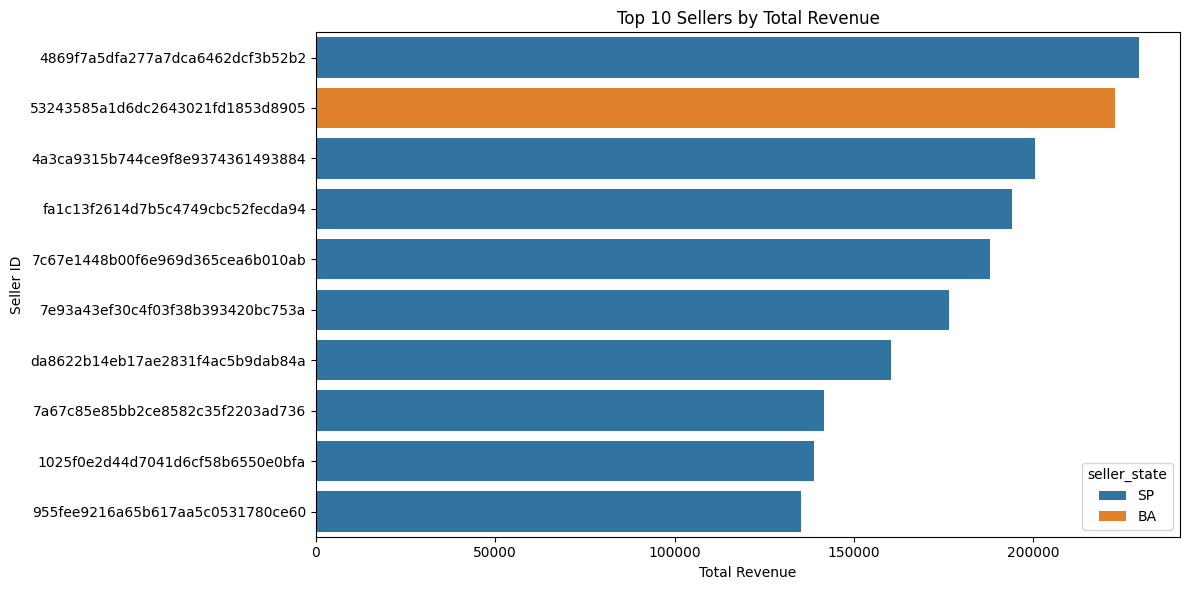

In [16]:
import pandas as pd
import numpy as np
sellers_df = pd.read_csv('/kaggle/input/project-for-python/sellers.csv', encoding='latin1')
order_items = pd.read_csv('/kaggle/input/project-for-python/order_items.csv')
seller_revenue = order_items_df.groupby('seller_id')['price'].sum().reset_index()
seller_revenue.columns = ['seller_id', 'total_revenue']
seller_ranking = seller_revenue.merge(sellers_df, on='seller_id', how='left')
seller_ranking = seller_ranking.sort_values('total_revenue', ascending=False)
seller_ranking['rank'] = range(1, len(seller_ranking) + 1)
print(seller_ranking[['rank', 'seller_id', 'total_revenue', 'seller_city', 'seller_state']].head(10))
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
top_10_sellers = seller_ranking.head(10)
sns.barplot(data=top_10_sellers, x='total_revenue', y='seller_id', hue='seller_state', dodge=False)
plt.title('Top 10 Sellers by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()

**11.Calculate the moving average of order values for each customer over thier order history**

In [17]:
import pandas as pd
orders = pd.read_csv('/kaggle/input/project-for-python/orders.csv', parse_dates=['order_purchase_timestamp'])
payments = pd.read_csv('/kaggle/input/project-for-python/payments.csv')
order_payments = orders.merge(payments, on='order_id', how='left')
order_values = (order_payments.groupby(['customer_id', 'order_id', 'order_purchase_timestamp'])['payment_value']
                              .sum()
                              .reset_index())
order_values = order_values.sort_values(by=['customer_id', 'order_purchase_timestamp'])
order_values['moving_avg_order_value'] = (order_values.groupby('customer_id')['payment_value']
                                                      .expanding()
                                                      .mean()
                                                      .reset_index(level=0, drop=True))
print(order_values.head(10))

                        customer_id                          order_id  \
0  00012a2ce6f8dcda20d059ce98491703  5f79b5b0931d63f1a42989eb65b9da6e   
1  000161a058600d5901f007fab4c27140  a44895d095d7e0702b6a162fa2dbeced   
2  0001fd6190edaaf884bcaf3d49edf079  316a104623542e4d75189bb372bc5f8d   
3  0002414f95344307404f0ace7a26f1d5  5825ce2e88d5346438686b0bba99e5ee   
4  000379cdec625522490c315e70c7a9fb  0ab7fb08086d4af9141453c91878ed7a   
5  0004164d20a9e969af783496f3408652  cd3558a10d854487b4f907e9b326a4fc   
6  000419c5494106c306a97b5635748086  07f6c3baf9ac86865b60f640c4f923c6   
7  00046a560d407e99b969756e0b10f282  8c3d752c5c02227878fae49aeaddbfd7   
8  00050bf6e01e69d5c0fd612f1bcfb69c  fa906f338cee30a984d0945b3832e431   
9  000598caf2ef4117407665ac33275130  9b961b894e797f63622137ff7eb1c1af   

  order_purchase_timestamp  payment_value  moving_avg_order_value  
0      2017-11-14 16:08:26         114.74                  114.74  
1      2017-07-16 09:40:32          67.41                   

**12:-Calcuated the cumulative sales per month for each year**

In [18]:
import pandas as pd
orders_payments = pd.merge(orders, payments, on='order_id')
orders_payments['order_year'] = pd.to_datetime(orders_payments['order_purchase_timestamp']).dt.year
orders_payments['order_month'] = pd.to_datetime(orders_payments['order_purchase_timestamp']).dt.month
monthly_sales = (orders_payments
                 .groupby(['order_year','order_month'])['payment_value']
                 .sum()
                 .reset_index()
                 .sort_values(['order_year','order_month']))
monthly_sales['cumulative_sales'] = (monthly_sales
                                     .groupby('order_year')['payment_value']
                                     .cumsum())
print(monthly_sales)


    order_year  order_month  payment_value  cumulative_sales
0         2016            9         252.24            252.24
1         2016           10       59090.48          59342.72
2         2016           12          19.62          59362.34
3         2017            1      138488.04         138488.04
4         2017            2      291908.01         430396.05
5         2017            3      449863.60         880259.65
6         2017            4      417788.03        1298047.68
7         2017            5      592918.82        1890966.50
8         2017            6      511276.38        2402242.88
9         2017            7      592382.92        2994625.80
10        2017            8      674396.32        3669022.12
11        2017            9      727762.45        4396784.57
12        2017           10      779677.88        5176462.45
13        2017           11     1194882.80        6371345.25
14        2017           12      878401.48        7249746.73
15        2018          

**13:-Calculate the year-over-year growth rate of Total sales.**

In [19]:
orders_payments = pd.merge(orders, payments, on='order_id')
orders_payments['order_year'] = pd.to_datetime(
    orders_payments['order_purchase_timestamp']
).dt.year
yearly_sales = (orders_payments
                .groupby('order_year')['payment_value']
                .sum()
                .reset_index()
                .sort_values('order_year'))
yearly_sales['prev_year_sales'] = yearly_sales['payment_value'].shift(1)
yearly_sales['yoy_growth_percent'] = (
    (yearly_sales['payment_value'] - yearly_sales['prev_year_sales'])
    / yearly_sales['prev_year_sales']
) * 100

print(yearly_sales)


   order_year  payment_value  prev_year_sales  yoy_growth_percent
0        2016       59362.34              NaN                 NaN
1        2017     7249746.73         59362.34        12112.703761
2        2018     8699763.05       7249746.73           20.000924


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


**14:-Calculate the retention rate of customers, defined as the percentage of customer who make another purchase within 6 months of their first purchase**

In [20]:
import pandas as pd
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
first_orders = orders.groupby('customer_id')['order_purchase_timestamp'].min().reset_index()
first_orders.rename(columns={'order_purchase_timestamp':'first_order_date'}, inplace=True)
merged = pd.merge(orders, first_orders, on='customer_id')
next_orders = (merged[merged['order_purchase_timestamp'] > merged['first_order_date']]
               .groupby('customer_id')['order_purchase_timestamp']
               .min()
               .reset_index()
               .rename(columns={'order_purchase_timestamp':'next_order_date'}))
cust_orders = pd.merge(first_orders, next_orders, on='customer_id', how='left')
cust_orders['retained'] = (
    cust_orders['next_order_date'] <= cust_orders['first_order_date'] + pd.DateOffset(months=6)
)
retained_customers = cust_orders['retained'].sum()
total_customers = len(cust_orders)
retention_rate = (retained_customers / total_customers) * 100
print(f"Retention Rate (within 6 months): {retention_rate:.2f}%")


Retention Rate (within 6 months): 0.00%


**15:- dentify the top 3 customers who spent the most money in each year**

In [21]:
import pandas as pd
customers = pd.read_csv("/kaggle/input/project-for-python/Customers.csv")
orders = pd.read_csv("/kaggle/input/project-for-python/orders.csv")
payments = pd.read_csv("/kaggle/input/project-for-python/payments.csv")
merged = orders.merge(customers, on='customer_id').merge(payments, on='order_id')
merged['order_year'] = pd.to_datetime(merged['order_purchase_timestamp']).dt.year
yearly_spending = (merged
                   .groupby(['order_year', 'customer_id'])['payment_value']
                   .sum()
                   .reset_index(name='total_spent'))
yearly_spending['rank'] = yearly_spending.groupby('order_year')['total_spent']\
                                         .rank(method='dense', ascending=False)
top3_customers = yearly_spending[yearly_spending['rank'] <= 3]\
                   .sort_values(['order_year', 'rank'])
print(top3_customers)


       order_year                       customer_id  total_spent  rank
222          2016  a9dc96b027d1252bbac0a9b72d837fc6      1423.55   1.0
38           2016  1d34ed25963d5aae4cf3d7f3a4cda173      1400.74   2.0
84           2016  4a06381959b6670756de02e07b83815f      1227.78   3.0
4217         2017  1617b1357756262bfa56ab541c47bc16     13664.08   1.0
35452        2017  c6e2731c5b391845f6800c97401a43a9      6929.31   2.0
11540        2017  3fd6777bbce08a352fddd04e4a7cc8f6      6726.66   3.0
95348        2018  ec5b2ba62e574342386871631fafd3fc      7274.88   1.0
97086        2018  f48d464a0baaea338cb25f816991ab1f      6922.21   2.0
92872        2018  e0a2412720e9ea4f26c1ac985f6a7358      4809.44   3.0
